# XLM-R Fine-tuning for Multilingual Hate Speech Detection
Fine-tunes `xlm-roberta-large` on multilingual (EN/IT/SI) hate speech data.
Run this notebook **twice**: once with `ANNOTATION_SOURCE = 'human'`, once with `ANNOTATION_SOURCE = 'llm'`.

## 0. Install dependencies

In [1]:
!pip install transformers datasets scikit-learn torch --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
print(os.listdir('/content/drive'))


['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


## 1. Configuration — change settings here

In [4]:
import os

# ── Which annotation source to train on ──
# 'human' → uses EN/IT/SI_human_annotations.csv
# 'llm'   → uses EN/IT/SI_LLM_annotations.csv
ANNOTATION_SOURCE = 'human'  # <--- CHANGE THIS between runs

# ── Paths ──
DATA_DIR   = '/content/drive/MyDrive/training_data'
OUTPUT_DIR = f'/content/drive/MyDrive/Models/xlmr_{ANNOTATION_SOURCE}'
LANGUAGES       = ['EN', 'IT', 'SI']

# ── Model ──
MODEL_NAME      = 'xlm-roberta-large'
NUM_LABELS      = 4
MAX_LENGTH      = 128

# ── Hyperparameters (from Grigor et al. 2024) ──
LEARNING_RATE   = 6e-6
BATCH_SIZE      = 8
NUM_EPOCHS      = 3
VAL_SPLIT       = 0.2
RANDOM_SEED     = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Annotation source : {ANNOTATION_SOURCE}')
print(f'Output directory  : {OUTPUT_DIR}')

Annotation source : human
Output directory  : /content/drive/MyDrive/Models/xlmr_human


## 2. Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Check GPU

In [6]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : NVIDIA A100-SXM4-40GB
VRAM  : 42.4 GB


## 4. Load and prepare data

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

print(f'DATA_DIR: {DATA_DIR}')
print(f'ANNOTATION_SOURCE: {ANNOTATION_SOURCE}')
for lang in LANGUAGES:
    suffix = 'human_annotations' if ANNOTATION_SOURCE == 'human' else 'LLM_annotations'
    path = os.path.join(DATA_DIR, f'{lang}_{suffix}.csv')
    print(f'  {path} exists: {os.path.exists(path)}')

def load_language(lang, source):
    """Load one language CSV, drop errors, return comment-level DataFrame."""
    suffix = 'human_annotations' if source == 'human' else 'LLM_annotations'
    path = os.path.join(DATA_DIR, f'{lang}_{suffix}.csv')
    df = pd.read_csv(path)

    # Keep only valid labels
    df = df[pd.to_numeric(df['label_run1'], errors='coerce').isin([0,1,2,3])]
    df = df[pd.to_numeric(df['label_run2'], errors='coerce').isin([0,1,2,3])]
    df['label_run1'] = pd.to_numeric(df['label_run1']).astype(int)
    df['label_run2'] = pd.to_numeric(df['label_run2']).astype(int)

    df['lang'] = lang

    # Stratification key: rounded mean of both labels
    df['strat_label'] = ((df['label_run1'] + df['label_run2']) / 2).round().astype(int)

    print(f'  [{lang}] loaded {len(df)} comments')
    return df


def split_comments(df, val_split, seed):
    """
    Split at comment level (not row level) stratified by strat_label.
    Returns train_df, val_df still in wide format (one row per comment).
    """
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_split, random_state=seed)
    idx = np.arange(len(df))
    train_idx, val_idx = next(sss.split(idx, df['strat_label']))
    return df.iloc[train_idx].copy(), df.iloc[val_idx].copy()


def to_long(df):
    """
    Convert wide format (label_run1, label_run2) to long format.
    Each comment becomes 2 rows, one per label.
    No data leakage: split was done before this step.
    """
    rows = []
    for _, row in df.iterrows():
        for run in ['label_run1', 'label_run2']:
            rows.append({'text': row['text'], 'label': row[run], 'lang': row['lang']})
    return pd.DataFrame(rows).reset_index(drop=True)


print(f'Loading {ANNOTATION_SOURCE} annotations...')
train_parts, val_parts = [], []

for lang in LANGUAGES:
    df = load_language(lang, ANNOTATION_SOURCE)
    train_df, val_df = split_comments(df, VAL_SPLIT, RANDOM_SEED)
    train_parts.append(train_df)
    val_parts.append(val_df)
    print(f'  [{lang}] train: {len(train_df)} | val: {len(val_df)} comments')

# Pool languages
train_wide = pd.concat(train_parts, ignore_index=True)
val_wide   = pd.concat(val_parts,   ignore_index=True)

# Convert to long format AFTER split to prevent leakage
train_long = to_long(train_wide)
val_long   = to_long(val_wide)

print(f'\nFinal dataset (long format):')
print(f'  Train rows : {len(train_long)}')
print(f'  Val rows   : {len(val_long)}')
print(f'\nLabel distribution (train):')
print(train_long['label'].value_counts().sort_index())

DATA_DIR: /content/drive/MyDrive/training_data
ANNOTATION_SOURCE: human
  /content/drive/MyDrive/training_data/EN_human_annotations.csv exists: True
  /content/drive/MyDrive/training_data/IT_human_annotations.csv exists: True
  /content/drive/MyDrive/training_data/SI_human_annotations.csv exists: True
Loading human annotations...
  [EN] loaded 51094 comments
  [EN] train: 40875 | val: 10219 comments
  [IT] loaded 59227 comments
  [IT] train: 47381 | val: 11846 comments
  [SI] loaded 49696 comments
  [SI] train: 39756 | val: 9940 comments

Final dataset (long format):
  Train rows : 256024
  Val rows   : 64010

Label distribution (train):
label
0    151762
1      8775
2     89808
3      5679
Name: count, dtype: int64


## 5. Compute class weights

In [8]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2, 3])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_long['label'].values
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print('Class weights (inversely proportional to frequency):')
for i, w in enumerate(weights):
    print(f'  Class {i}: {w:.4f}')

Class weights (inversely proportional to frequency):
  Class 0: 0.4218
  Class 1: 7.2941
  Class 2: 0.7127
  Class 3: 11.2706


## 6. Tokenise

In [9]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

print(f'Loading tokeniser: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts  = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = HateSpeechDataset(train_long, tokenizer, MAX_LENGTH)
val_dataset   = HateSpeechDataset(val_long,   tokenizer, MAX_LENGTH)
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

Loading tokeniser: xlm-roberta-large


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Train samples: 256024 | Val samples: 64010


## 7. DataLoaders

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 32003 | Val batches: 8002


## 8. Load model

In [11]:
from transformers import AutoModelForSequenceClassification

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(device)
print('Model loaded and moved to device.')

Loading model: xlm-roberta-large


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to device.


## 9. Optimizer and loss

In [12]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)   # 10% warmup
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Weighted cross-entropy loss (inversely proportional to class frequency)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f'Total steps : {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Total steps : 96009
Warmup steps: 9600


## 10. Training loop

In [13]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = loss_fn(outputs.logits, labels)
            total_loss    += loss.item()
            preds          = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, accuracy


best_val_f1   = 0.0
best_epoch    = 0
history       = []

print(f'Starting training ({NUM_EPOCHS} epochs)...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_f1, val_acc = evaluate(model, val_loader)

    history.append({
        'epoch':      epoch,
        'train_loss': avg_train_loss,
        'val_loss':   val_loss,
        'val_f1':     val_f1,
        'val_acc':    val_acc
    })

    print(f'Epoch {epoch}/{NUM_EPOCHS}')
    print(f'  Train loss : {avg_train_loss:.4f}')
    print(f'  Val loss   : {val_loss:.4f}')
    print(f'  Val macro F1: {val_f1:.4f}')
    print(f'  Val accuracy: {val_acc:.4f}')

    # Save best model checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print(f'  ✓ New best model saved (val F1={val_f1:.4f})')
    print()

print(f'Training complete. Best val macro F1: {best_val_f1:.4f} at epoch {best_epoch}')
print(f'Model saved to: {OUTPUT_DIR}')

Starting training (3 epochs)...

  Epoch 1 | Step 200/32003 | Loss: 1.3367
  Epoch 1 | Step 400/32003 | Loss: 1.4373
  Epoch 1 | Step 600/32003 | Loss: 1.1598
  Epoch 1 | Step 800/32003 | Loss: 0.8768
  Epoch 1 | Step 1000/32003 | Loss: 0.7851
  Epoch 1 | Step 1200/32003 | Loss: 2.0707
  Epoch 1 | Step 1400/32003 | Loss: 0.9038
  Epoch 1 | Step 1600/32003 | Loss: 0.7827
  Epoch 1 | Step 1800/32003 | Loss: 0.7459
  Epoch 1 | Step 2000/32003 | Loss: 2.1026
  Epoch 1 | Step 2200/32003 | Loss: 0.8411
  Epoch 1 | Step 2400/32003 | Loss: 0.6706
  Epoch 1 | Step 2600/32003 | Loss: 2.0294
  Epoch 1 | Step 2800/32003 | Loss: 0.5605
  Epoch 1 | Step 3000/32003 | Loss: 2.1812
  Epoch 1 | Step 3200/32003 | Loss: 0.8146
  Epoch 1 | Step 3400/32003 | Loss: 0.4740
  Epoch 1 | Step 3600/32003 | Loss: 0.3372
  Epoch 1 | Step 3800/32003 | Loss: 0.7267
  Epoch 1 | Step 4000/32003 | Loss: 2.6167
  Epoch 1 | Step 4200/32003 | Loss: 0.2556
  Epoch 1 | Step 4400/32003 | Loss: 1.7412
  Epoch 1 | Step 4600/320

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val F1=0.6609)

  Epoch 2 | Step 200/32003 | Loss: 2.5401
  Epoch 2 | Step 400/32003 | Loss: 0.7148
  Epoch 2 | Step 600/32003 | Loss: 0.5426
  Epoch 2 | Step 800/32003 | Loss: 0.4970
  Epoch 2 | Step 1000/32003 | Loss: 0.2889
  Epoch 2 | Step 1200/32003 | Loss: 0.8320
  Epoch 2 | Step 1400/32003 | Loss: 1.0112
  Epoch 2 | Step 1600/32003 | Loss: 0.3108
  Epoch 2 | Step 1800/32003 | Loss: 0.0349
  Epoch 2 | Step 2000/32003 | Loss: 0.9877
  Epoch 2 | Step 2200/32003 | Loss: 2.5541
  Epoch 2 | Step 2400/32003 | Loss: 3.1210
  Epoch 2 | Step 2600/32003 | Loss: 0.4477
  Epoch 2 | Step 2800/32003 | Loss: 1.1239
  Epoch 2 | Step 3000/32003 | Loss: 0.3093
  Epoch 2 | Step 3200/32003 | Loss: 0.6656
  Epoch 2 | Step 3400/32003 | Loss: 1.0169
  Epoch 2 | Step 3600/32003 | Loss: 0.9779
  Epoch 2 | Step 3800/32003 | Loss: 0.1349
  Epoch 2 | Step 4000/32003 | Loss: 0.6655
  Epoch 2 | Step 4200/32003 | Loss: 0.1706
  Epoch 2 | Step 4400/32003 | Loss: 0.3360
  Epoch 2 | Step

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val F1=0.6733)

  Epoch 3 | Step 200/32003 | Loss: 0.6367
  Epoch 3 | Step 400/32003 | Loss: 0.7594
  Epoch 3 | Step 600/32003 | Loss: 1.7495
  Epoch 3 | Step 800/32003 | Loss: 0.0668
  Epoch 3 | Step 1000/32003 | Loss: 0.3074
  Epoch 3 | Step 1200/32003 | Loss: 0.0579
  Epoch 3 | Step 1400/32003 | Loss: 0.1165
  Epoch 3 | Step 1600/32003 | Loss: 1.6306
  Epoch 3 | Step 1800/32003 | Loss: 1.2661
  Epoch 3 | Step 2000/32003 | Loss: 0.1171
  Epoch 3 | Step 2200/32003 | Loss: 0.1479
  Epoch 3 | Step 2400/32003 | Loss: 0.9380
  Epoch 3 | Step 2600/32003 | Loss: 0.1693
  Epoch 3 | Step 2800/32003 | Loss: 0.6440
  Epoch 3 | Step 3000/32003 | Loss: 3.0315
  Epoch 3 | Step 3200/32003 | Loss: 0.0894
  Epoch 3 | Step 3400/32003 | Loss: 0.1164
  Epoch 3 | Step 3600/32003 | Loss: 0.7223
  Epoch 3 | Step 3800/32003 | Loss: 0.0533
  Epoch 3 | Step 4000/32003 | Loss: 0.0497
  Epoch 3 | Step 4200/32003 | Loss: 0.4662
  Epoch 3 | Step 4400/32003 | Loss: 0.3678
  Epoch 3 | Step

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val F1=0.6829)

Training complete. Best val macro F1: 0.6829 at epoch 3
Model saved to: /content/drive/MyDrive/Models/xlmr_human


## 11. Training history

 epoch  train_loss  val_loss   val_f1  val_acc
     1    0.900793  0.846846 0.660905 0.792611
     2    0.709947  0.731812 0.673312 0.784721
     3    0.607255  0.855682 0.682859 0.799891


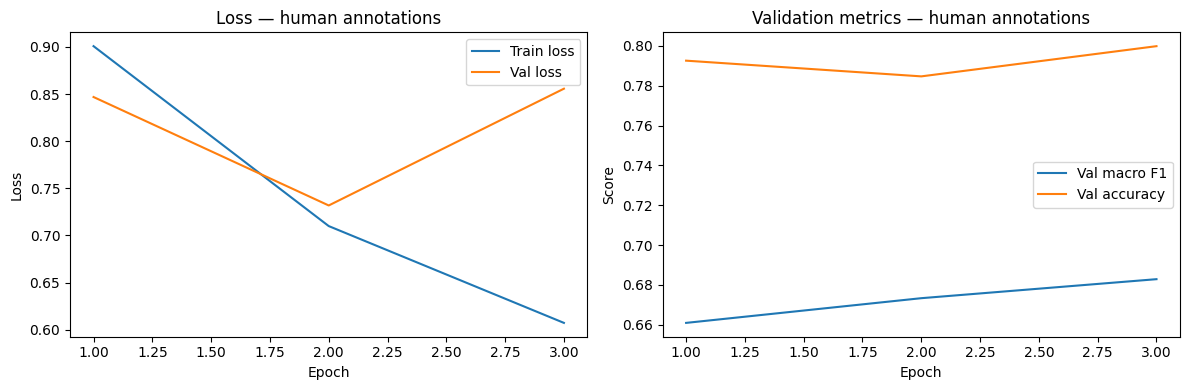

Plot saved.


In [14]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
print(hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss — {ANNOTATION_SOURCE} annotations')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1'],  label='Val macro F1')
axes[1].plot(hist_df['epoch'], hist_df['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title(f'Validation metrics — {ANNOTATION_SOURCE} annotations')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()
print('Plot saved.')

## 12. Save training history to CSV

In [15]:
hist_path = os.path.join(OUTPUT_DIR, 'training_history.csv')
hist_df.to_csv(hist_path, index=False)
print(f'Training history saved to {hist_path}')

Training history saved to /content/drive/MyDrive/Models/xlmr_human/training_history.csv
